#  Projet Biométrie — Reconnaissance Faciale sur AT&T Database of Faces

Dataset : [AT&T Database of Faces](https://www.kaggle.com/datasets/kasikrit/att-database-of-faces/data)  
- 40 sujets × 10 images = 400 images  
- Split : 8 images train / 2 images test par sujet  
- Format : PGM, résolution 92×112 pixels, 256 niveaux de gris  

Méthodes comparées :
1. LBPH (Local Binary Patterns Histograms) — descripteur de texture + distance Chi²  
2. Eigenfaces — réduction dimensionnelle + classifieur à marge maximale


##  Imports et configuration

In [1]:
import os
import time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, precision_recall_fscore_support)
from skimage.feature import local_binary_pattern

print(" Imports terminés")


 Imports terminés


## 1. Chargement du dataset

Le dataset AT&T est chargé depuis le chemin Kaggle. Chaque image PGM est lue via PIL
et convertie en tableau NumPy. Les labels vont de 0 à 39 (40 sujets).


In [2]:
DATASET_PATH = "/kaggle/input/datasets/kasikrit/att-database-of-faces"

def load_dataset(dataset_path):
    X, y = [], []
    for subject_id in range(1, 41):           # s1 à s40
        folder = os.path.join(dataset_path, f"s{subject_id}")
        for image_id in range(1, 11):         # 1.pgm à 10.pgm
            img_path = os.path.join(folder, f"{image_id}.pgm")
            img = Image.open(img_path)
            X.append(np.array(img))
            y.append(subject_id - 1)          # labels 0-39
    return np.array(X), np.array(y)

X, y = load_dataset(DATASET_PATH)

print(f"Shape images  : {X.shape}  →  (N, hauteur, largeur)")
print(f"Shape labels  : {y.shape}")
print(f"Valeurs pixel : {X.min()} – {X.max()}")
print(f"Sujets        : {len(np.unique(y))}")


Shape images  : (400, 112, 92)  →  (N, hauteur, largeur)
Shape labels  : (400,)
Valeurs pixel : 0 – 251
Sujets        : 40


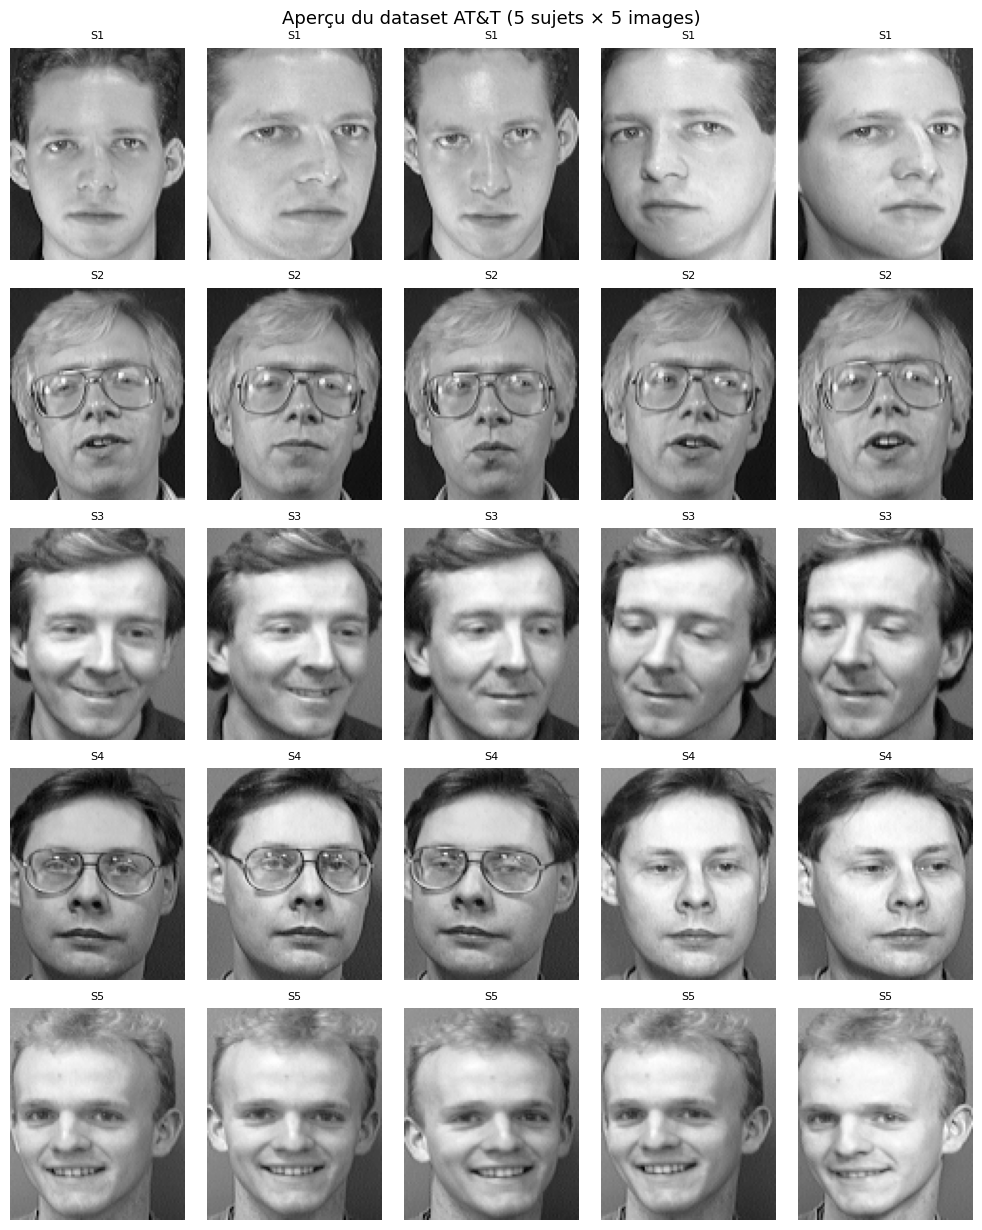

In [3]:
def show_sample(X, y, n_subjects=5, n_images=5):
    fig, axes = plt.subplots(n_subjects, n_images, figsize=(n_images * 2, n_subjects * 2.5))
    for i in range(n_subjects):
        indices = np.where(y == i)[0][:n_images]
        for j, idx in enumerate(indices):
            axes[i, j].imshow(X[idx], cmap='gray')
            axes[i, j].axis('off')
            axes[i, j].set_title(f"S{i+1}", fontsize=8)
    plt.suptitle("Aperçu du dataset AT&T (5 sujets × 5 images)", fontsize=13)
    plt.tight_layout()
    plt.show()

show_sample(X, y)


## 2. Split Train / Test

Split stratifié manuel : **8 images** d'entraînement et **2 images** de test par sujet,  
soit 320 images train et 80 images test au total.


In [4]:
def split_dataset(X, y, n_train=8):
    X_train, X_test, y_train, y_test = [], [], [], []
    for subject_id in range(40):
        indices = np.where(y == subject_id)[0]
        np.random.shuffle(indices)
        X_train.append(X[indices[:n_train]])
        X_test.append(X[indices[n_train:]])
        y_train.append(y[indices[:n_train]])
        y_test.append(y[indices[n_train:]])
    return (np.concatenate(X_train), np.concatenate(X_test),
            np.concatenate(y_train), np.concatenate(y_test))

np.random.seed(42)
X_train, X_test, y_train, y_test = split_dataset(X, y)

print(f"X_train : {X_train.shape}  →  {len(np.unique(y_train))} sujets × 8 images")
print(f"X_test  : {X_test.shape}   →  {len(np.unique(y_test))} sujets × 2 images")


X_train : (320, 112, 92)  →  40 sujets × 8 images
X_test  : (80, 112, 92)   →  40 sujets × 2 images


---
##  Méthode 1 — LBPH (Local Binary Patterns Histograms)

### Principe

Le **LBP** (Local Binary Pattern) est un descripteur de texture local :  
pour chaque pixel, on compare sa valeur aux voisins sur un cercle de rayon `R`.  
Le résultat est un code binaire encodant la micro-texture locale.

L'image est ensuite découpée en **blocs** et un histogramme LBP est calculé  
par bloc → les histogrammes concaténés forment le **descripteur LBPH** de l'image.

**Classification** : comparaison par distance **Chi²** entre le descripteur test  
et le modèle moyen de chaque sujet. Le sujet le plus proche gagne.

**Paramètres clés :**
- `RADIUS = 1` : rayon du voisinage
- `N_POINTS = 8` : nombre de voisins
- `METHOD = 'uniform'` : seuls les patterns avec ≤ 2 transitions binaires sont conservés
- `BLOCK_SIZE = 8` : taille des blocs en pixels


In [5]:
# ── Paramètres LBP ────────────────────────────────────────────────────────────
RADIUS     = 1
N_POINTS   = 8 * RADIUS
METHOD     = 'uniform'
BLOCK_SIZE = 8

# ── Fonctions de distance ──────────────────────────────────────────────────────
def chi2_distance(hist1, hist2, eps=1e-10):
    """Distance Chi² entre deux histogrammes normalisés."""
    return 0.5 * np.sum(((hist1 - hist2) ** 2) / (hist1 + hist2 + eps))

def euclidean_distance(hist1, hist2):
    """Distance Euclidienne entre deux histogrammes."""
    return np.sqrt(np.sum((hist1 - hist2) ** 2))

def kl_divergence(hist1, hist2, eps=1e-10):
    """Divergence de Kullback-Leibler symétrisée (KL(P||Q) + KL(Q||P)) / 2."""
    p = hist1 + eps
    q = hist2 + eps
    return 0.5 * (np.sum(p * np.log(p / q)) + np.sum(q * np.log(q / p)))

DISTANCE_FUNCTIONS = {
    'Chi²':       chi2_distance,
    'Euclidienne': euclidean_distance,
    'KL':         kl_divergence,
}

def compute_lbp_histogram(image, n_points, radius, method, n_bins):
    """Histogramme LBP normalisé d'un bloc d'image."""
    lbp = local_binary_pattern(image, n_points, radius, method)
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist

def compute_lbp_histograms(X, n_points, radius, method, block_size):
    """Descripteurs LBPH par blocs pour un ensemble d'images."""
    descriptors = []
    img_h, img_w = X[0].shape
    n_bins = n_points + 2       # uniform LBP → n_points + 2 bins
    for image in X:
        block_hists = []
        for row in range(0, img_h, block_size):
            for col in range(0, img_w, block_size):
                block = image[row:row+block_size, col:col+block_size]
                if block.shape[0] < block_size // 2 or block.shape[1] < block_size // 2:
                    continue
                block_hists.append(
                    compute_lbp_histogram(block, n_points, radius, method, n_bins)
                )
        descriptors.append(np.concatenate(block_hists))
    return np.array(descriptors)

def train_lbph(X_train, y_train, n_points, radius, method, block_size):
    """Entraîne LBPH : calcule le descripteur moyen par sujet."""
    print(f"Calcul des descripteurs LBPH (block_size={block_size})...")
    descriptors = compute_lbp_histograms(X_train, n_points, radius, method, block_size)
    subject_models = {}
    for sid in np.unique(y_train):
        idx = np.where(y_train == sid)[0]
        subject_models[sid] = descriptors[idx].mean(axis=0)
    print(f"  → {len(subject_models)} modèles | dim descripteur : {list(subject_models.values())[0].shape[0]}")
    return subject_models, descriptors

def predict_lbph(X_test, subject_models, n_points, radius, method, block_size,
                 distance_fn=None):
    """Prédit par plus proche voisin (distance configurable) sur les modèles moyens."""
    if distance_fn is None:
        distance_fn = chi2_distance
    test_descriptors = compute_lbp_histograms(X_test, n_points, radius, method, block_size)
    y_pred = []
    scores = []   # score de confiance = distance au plus proche voisin (min)
    for desc in test_descriptors:
        dists = {s: distance_fn(desc, subject_models[s]) for s in subject_models}
        best_sid = min(dists, key=dists.get)
        y_pred.append(best_sid)
        scores.append(dists[best_sid])
    return np.array(y_pred), test_descriptors, np.array(scores)

print(" Fonctions LBPH définies (Chi², Euclidienne, KL)")

 Fonctions LBPH définies (Chi², Euclidienne, KL)


In [6]:
# ── Entraînement LBPH ─────────────────────────────────────────────────────────
t0 = time.time()
subject_models, train_descriptors = train_lbph(
    X_train, y_train, N_POINTS, RADIUS, METHOD, BLOCK_SIZE
)
t1 = time.time()
TIME_LBPH_TRAIN = t1 - t0
print(f"Temps entraînement : {TIME_LBPH_TRAIN:.3f}s")

# ── Prédiction (Chi² par défaut) ───────────────────────────────────────────────
t2 = time.time()
y_pred_lbph, test_descriptors_lbph, scores_lbph = predict_lbph(
    X_test, subject_models, N_POINTS, RADIUS, METHOD, BLOCK_SIZE,
    distance_fn=chi2_distance
)
t3 = time.time()
TIME_LBPH_PRED = t3 - t2

print(f"Temps prédiction   : {TIME_LBPH_PRED:.4f}s")
print(f"Accuracy LBPH      : {accuracy_score(y_test, y_pred_lbph)*100:.2f}%")

Calcul des descripteurs LBPH (block_size=8)...
  → 40 modèles | dim descripteur : 1680
Temps entraînement : 7.759s
Temps prédiction   : 1.9340s
Accuracy LBPH      : 90.00%


### 1.1 Histogrammes LBPH par sujet

Chaque histogramme représente le **descripteur moyen** du sujet (moyenne sur ses 8 images).  
Des formes similaires indiquent des sujets potentiellement confondus ; des formes distinctes  
attestent d'une bonne séparabilité.


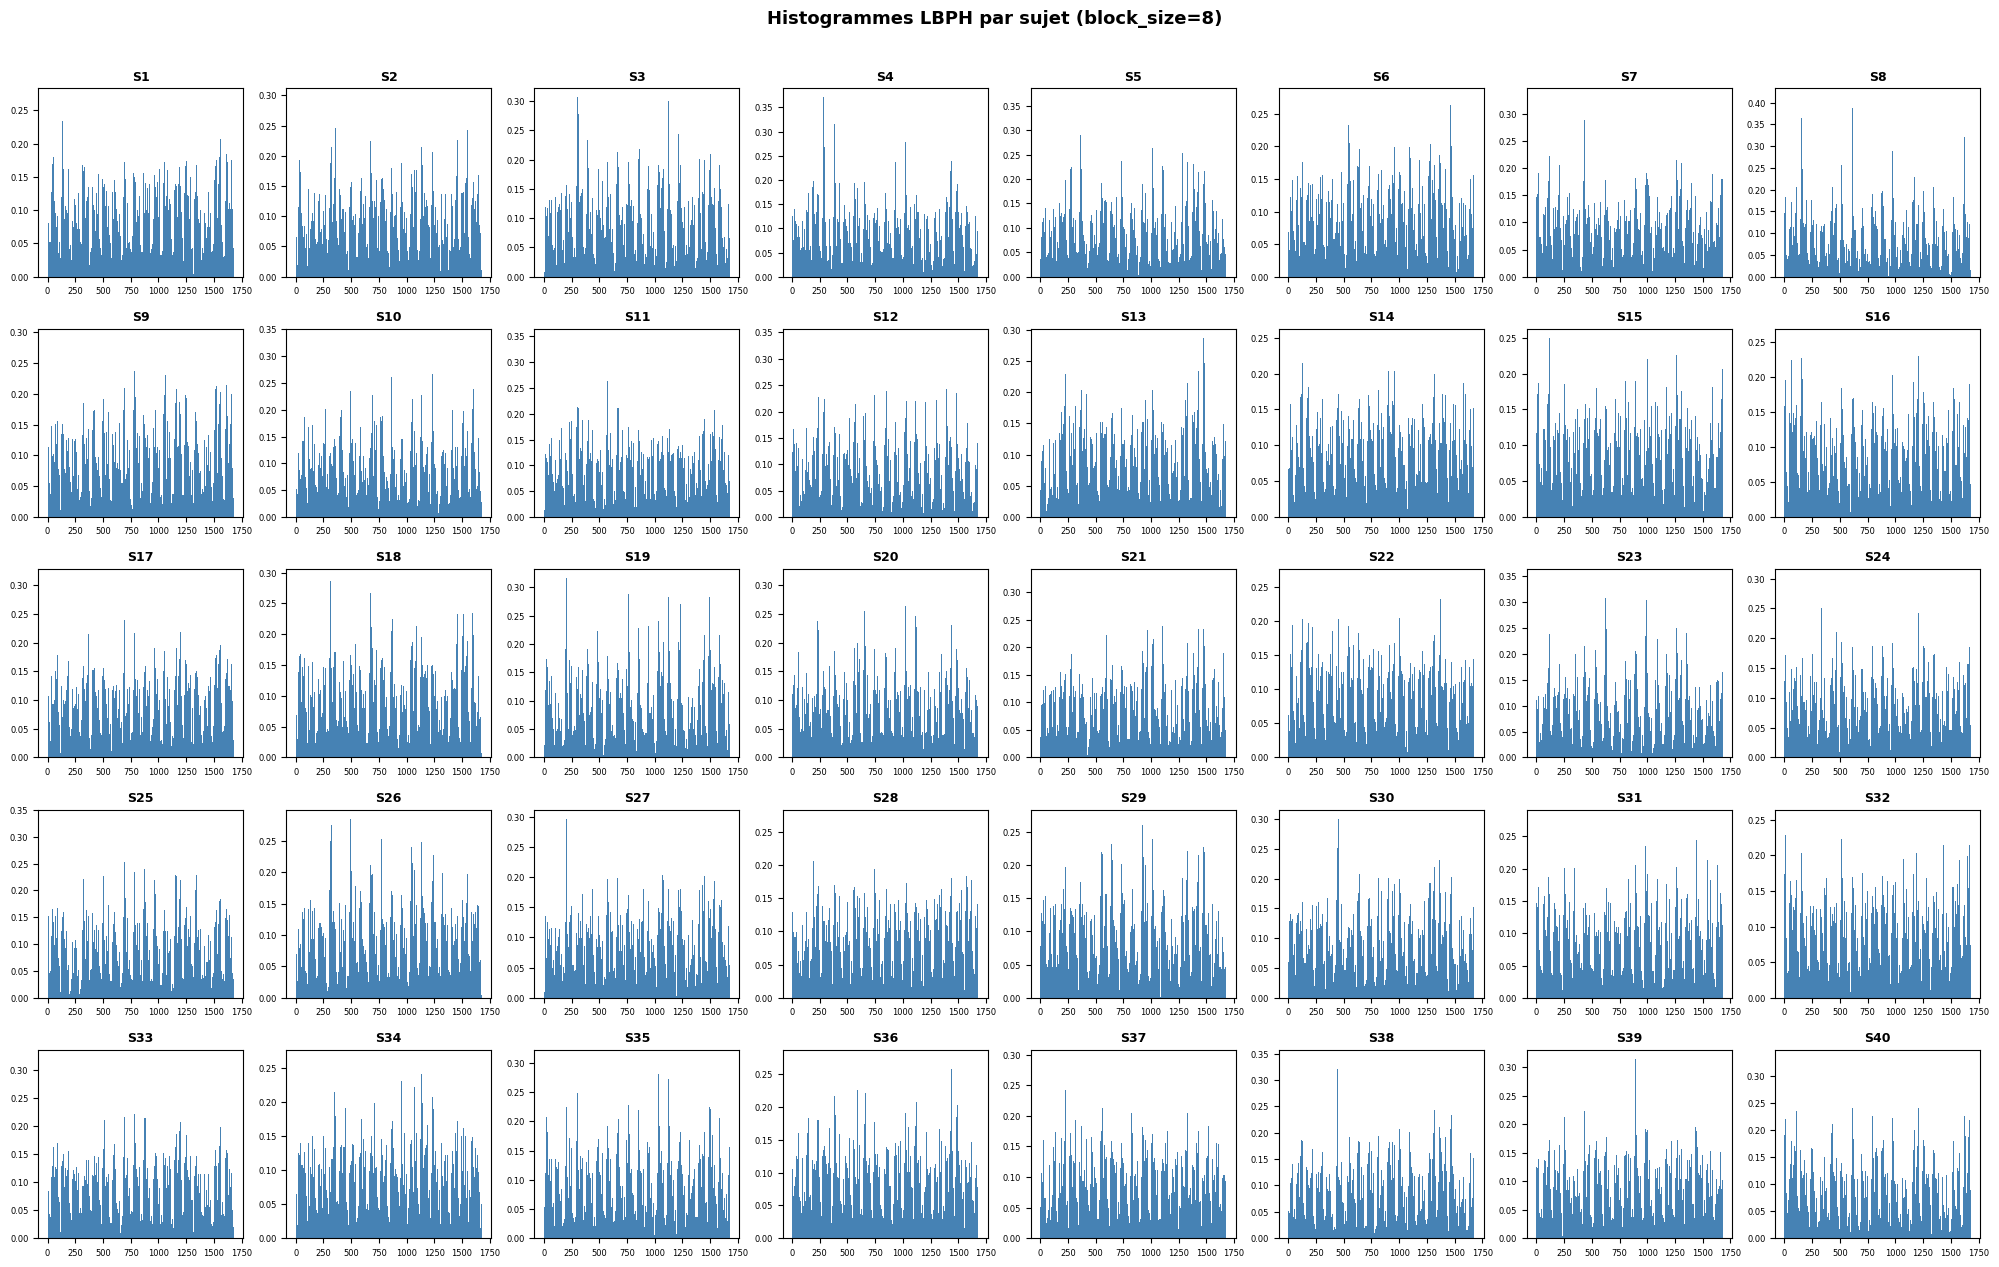

In [7]:
def plot_subject_histograms(subject_models, block_size, n_cols=8):
    n_subjects = len(subject_models)
    n_rows = int(np.ceil(n_subjects / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2.5))
    axes = axes.ravel()
    for sid, model in subject_models.items():
        axes[sid].bar(range(len(model)), model, color='steelblue', width=1.0, edgecolor='none')
        axes[sid].set_title(f"S{sid+1}", fontsize=9, fontweight='bold')
        axes[sid].tick_params(labelsize=6)
    for i in range(n_subjects, len(axes)):
        axes[i].set_visible(False)
    plt.suptitle(f"Histogrammes LBPH par sujet (block_size={block_size})",
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_subject_histograms(subject_models, BLOCK_SIZE)


### 1.2 Matrice de distances Chi² entre sujets

La diagonale doit être nulle (sujet vs lui-même). Les zones sombres hors diagonale  
révèlent les paires de sujets difficiles à distinguer → potentielles sources d'erreur.


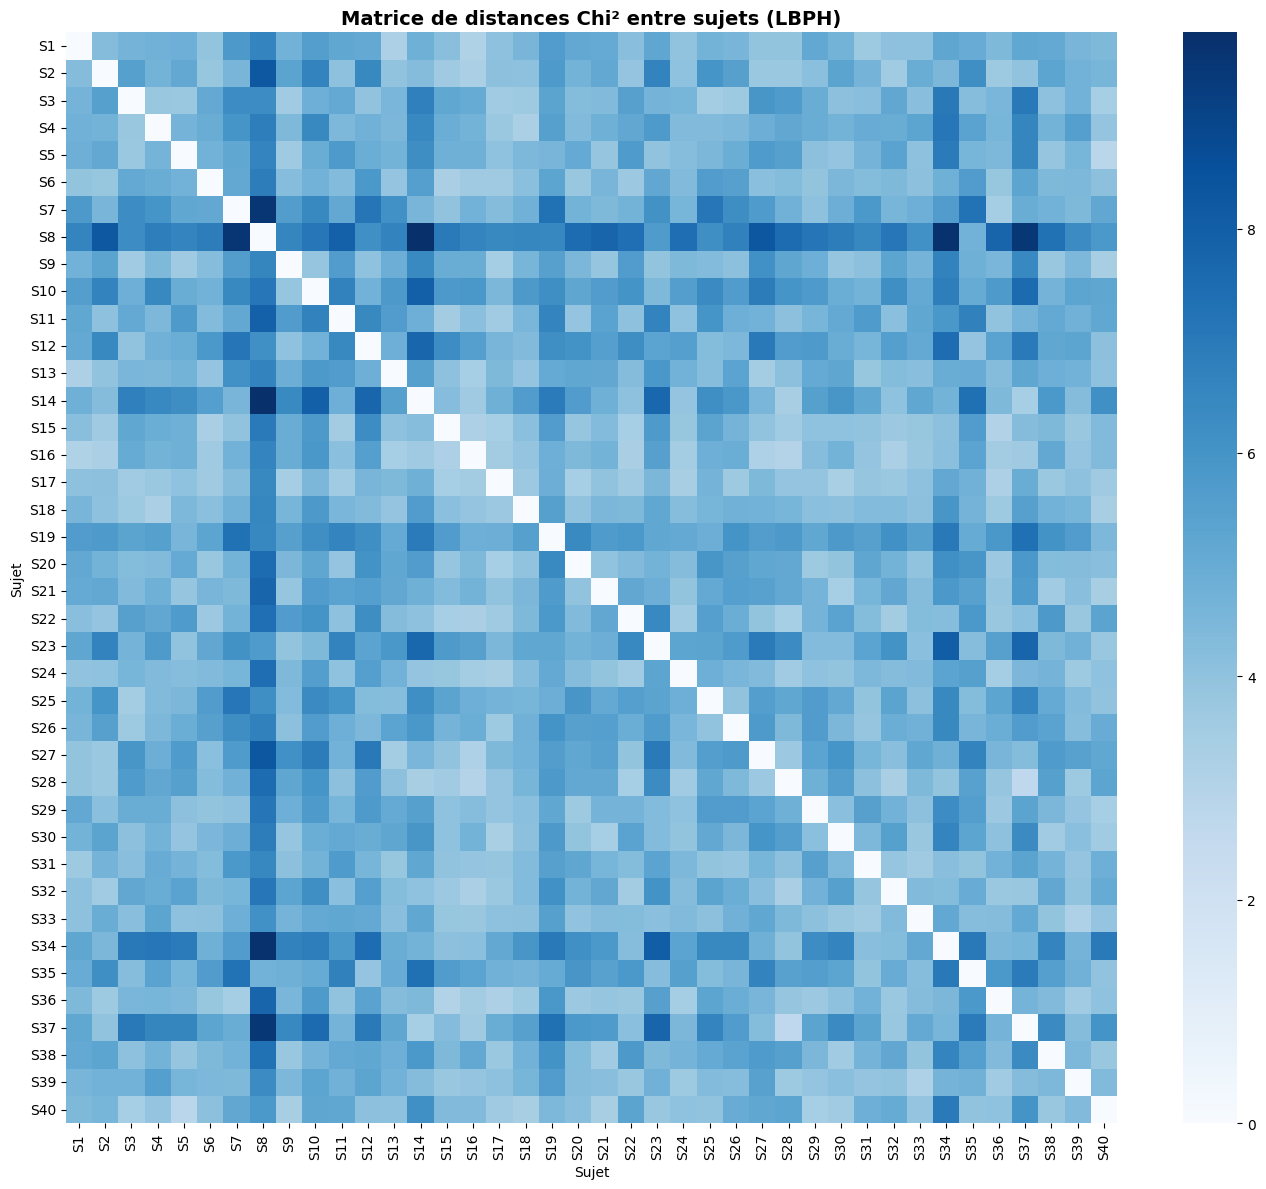

Intra-sujet  → moy: 0.0000 | max: 0.0000
Inter-sujet  → moy: 4.9238 | min: 2.6569
Ratio inter/intra : 49237799727.0×


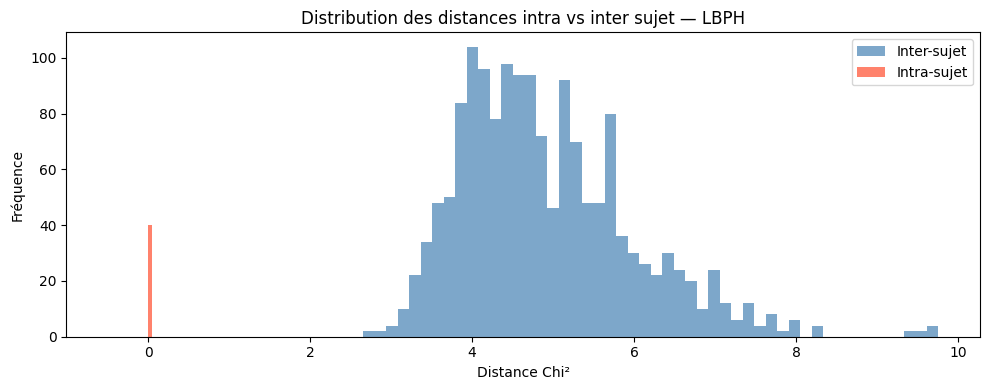

In [8]:
def plot_distance_matrix(subject_models):
    n = len(subject_models)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = chi2_distance(subject_models[i], subject_models[j])
    plt.figure(figsize=(14, 12))
    sns.heatmap(D, annot=False, cmap='Blues',
                xticklabels=[f"S{i+1}" for i in range(n)],
                yticklabels=[f"S{i+1}" for i in range(n)])
    plt.title("Matrice de distances Chi² entre sujets (LBPH)", fontsize=14, fontweight='bold')
    plt.xlabel("Sujet"); plt.ylabel("Sujet")
    plt.tight_layout(); plt.show()
    return D

distance_matrix = plot_distance_matrix(subject_models)

# Distribution intra vs inter
intra = [distance_matrix[i, i] for i in range(len(subject_models))]
inter = [distance_matrix[i, j] for i in range(len(subject_models))
                                for j in range(len(subject_models)) if i != j]
print(f"Intra-sujet  → moy: {np.mean(intra):.4f} | max: {max(intra):.4f}")
print(f"Inter-sujet  → moy: {np.mean(inter):.4f} | min: {min(inter):.4f}")
print(f"Ratio inter/intra : {np.mean(inter)/max(np.mean(intra), 1e-10):.1f}×")

plt.figure(figsize=(10, 4))
plt.hist(inter, bins=50, alpha=0.7, color='steelblue', label='Inter-sujet')
plt.hist(intra, bins=20, alpha=0.8, color='tomato',    label='Intra-sujet')
plt.xlabel("Distance Chi²"); plt.ylabel("Fréquence")
plt.title("Distribution des distances intra vs inter sujet — LBPH")
plt.legend(); plt.tight_layout(); plt.show()


### Sensibilité au paramètre `block_size` (LBPH)

On évalue l'accuracy LBPH pour différentes valeurs de `block_size` :  
- **Petit** (8) : beaucoup de blocs, textures fines, vecteur long  
- **Grand** (56) : peu de blocs, structure globale, moins de détails  


block_size = 4 ... Calcul des descripteurs LBPH (block_size=4)...
  → 40 modèles | dim descripteur : 6440
Accuracy : 82.5%
block_size = 8 ... Calcul des descripteurs LBPH (block_size=8)...
  → 40 modèles | dim descripteur : 1680
Accuracy : 90.0%
block_size = 14 ... Calcul des descripteurs LBPH (block_size=14)...
  → 40 modèles | dim descripteur : 560
Accuracy : 88.8%
block_size = 16 ... Calcul des descripteurs LBPH (block_size=16)...
  → 40 modèles | dim descripteur : 420
Accuracy : 85.0%
block_size = 28 ... Calcul des descripteurs LBPH (block_size=28)...
  → 40 modèles | dim descripteur : 120
Accuracy : 73.8%
block_size = 56 ... Calcul des descripteurs LBPH (block_size=56)...
  → 40 modèles | dim descripteur : 40
Accuracy : 50.0%


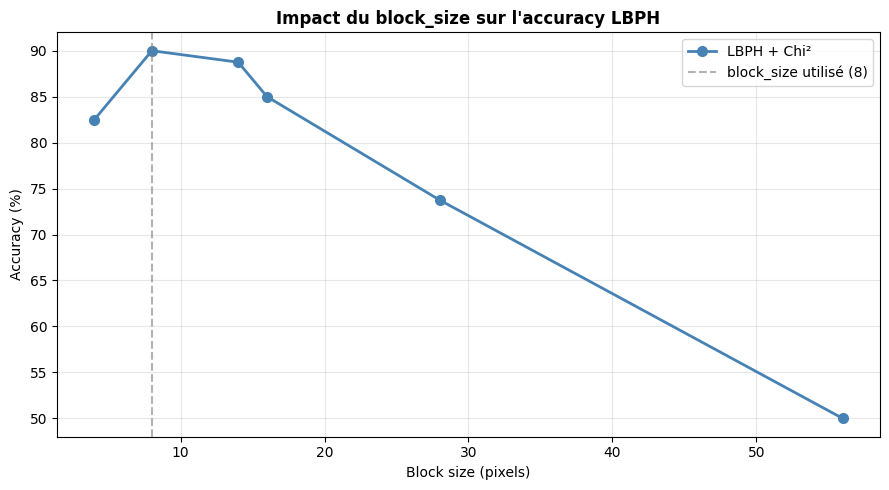

In [9]:
BLOCK_SIZES_TEST = [ 4, 8, 14, 16, 28, 56]
accs_lbph = []

for bs in BLOCK_SIZES_TEST:
    print(f"block_size = {bs} ...", end=" ", flush=True)
    models_bs, _ = train_lbph(X_train, y_train, N_POINTS, RADIUS, METHOD, bs)
    pred_bs, _, _ = predict_lbph(X_test, models_bs, N_POINTS, RADIUS, METHOD, bs)
    acc_bs  = accuracy_score(y_test, pred_bs)
    accs_lbph.append(acc_bs)
    print(f"Accuracy : {acc_bs*100:.1f}%")

# ── Graphique ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.plot(BLOCK_SIZES_TEST, [a*100 for a in accs_lbph],
         "o-", color="steelblue", linewidth=2, markersize=7, label="LBPH + Chi²")
plt.axvline(x=BLOCK_SIZE, color="gray", linestyle="--", alpha=0.6,
            label=f"block_size utilisé ({BLOCK_SIZE})")
plt.xlabel("Block size (pixels)"); plt.ylabel("Accuracy (%)")
plt.title("Impact du block_size sur l'accuracy LBPH", fontweight="bold")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


### 1.3 Courbe ROC — LBPH (Chi²)

La **courbe ROC** évalue la capacité du classifieur à séparer chaque sujet du reste  
dans un cadre **one-vs-rest**. L'AUC (Area Under Curve) synthétise la performance :  
- AUC = 1.0 : séparation parfaite  
- AUC = 0.5 : classifieur aléatoire  

La **distance Chi²** est inversée (négation) pour servir de score de confiance :  
une distance *faible* correspond à une *forte* probabilité d'appartenance au sujet.


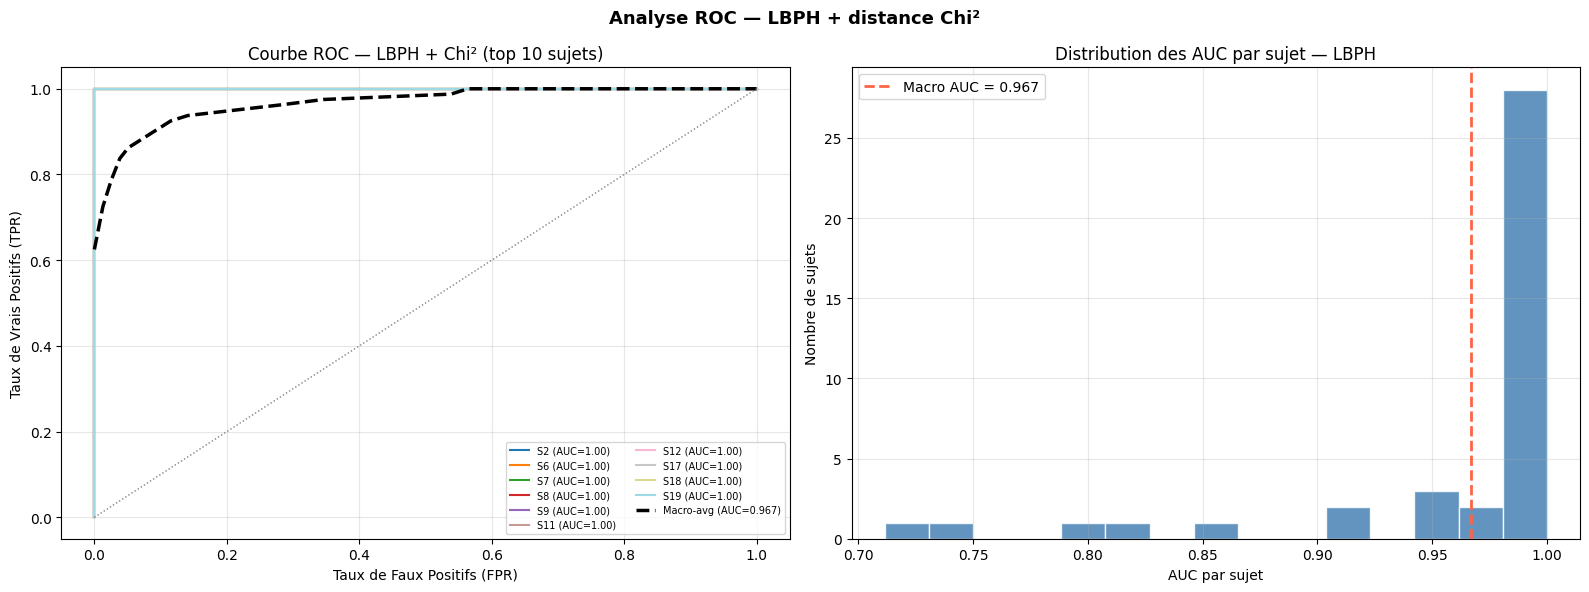


AUC macro-average : 0.9670
AUC min : 0.7115  |  AUC max : 1.0000
Sujets avec AUC < 0.95 : 8


In [10]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_roc_lbph(X_test, y_test, subject_models, n_points, radius, method,
                  block_size, distance_fn, distance_name, n_show=10):
    """
    Courbe ROC one-vs-rest pour LBPH.
    Le score de confiance pour le sujet s est : -distance(desc, model[s])
    (plus la distance est faible, plus le score est élevé).
    """
    classes = sorted(subject_models.keys())
    n_classes = len(classes)

    # Calcul des descripteurs de test
    test_descs = compute_lbp_histograms(X_test, n_points, radius, method, block_size)

    # Matrice de scores (N_test × N_classes) : score = −distance
    score_matrix = np.zeros((len(test_descs), n_classes))
    for j, sid in enumerate(classes):
        for i, desc in enumerate(test_descs):
            score_matrix[i, j] = -distance_fn(desc, subject_models[sid])

    # Binarisation des labels (one-vs-rest)
    y_bin = label_binarize(y_test, classes=classes)

    # Calcul AUC par classe
    fpr_all, tpr_all, roc_auc_all = {}, {}, {}
    for j, sid in enumerate(classes):
        fpr_all[sid], tpr_all[sid], _ = roc_curve(y_bin[:, j], score_matrix[:, j])
        roc_auc_all[sid] = auc(fpr_all[sid], tpr_all[sid])

    # Macro-average
    all_fpr = np.unique(np.concatenate([fpr_all[s] for s in classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for sid in classes:
        mean_tpr += np.interp(all_fpr, fpr_all[sid], tpr_all[sid])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    # ── Graphique : n_show courbes + macro-average ────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Gauche : quelques courbes individuelles
    ax = axes[0]
    palette = plt.cm.tab20(np.linspace(0, 1, n_show))
    sorted_sids = sorted(classes, key=lambda s: -roc_auc_all[s])
    for k, sid in enumerate(sorted_sids[:n_show]):
        ax.plot(fpr_all[sid], tpr_all[sid], color=palette[k], lw=1.5,
                label=f"S{sid+1} (AUC={roc_auc_all[sid]:.2f})")
    ax.plot(all_fpr, mean_tpr, 'k--', lw=2.5,
            label=f"Macro-avg (AUC={macro_auc:.3f})")
    ax.plot([0, 1], [0, 1], 'gray', linestyle=':', lw=1)
    ax.set_xlabel("Taux de Faux Positifs (FPR)"); ax.set_ylabel("Taux de Vrais Positifs (TPR)")
    ax.set_title(f"Courbe ROC — LBPH + {distance_name} (top {n_show} sujets)")
    ax.legend(fontsize=7, loc="lower right", ncol=2)
    ax.grid(alpha=0.3)

    # Droite : distribution des AUC
    auc_values = [roc_auc_all[s] for s in classes]
    ax2 = axes[1]
    ax2.hist(auc_values, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
    ax2.axvline(x=macro_auc, color='tomato', linestyle='--', lw=2,
                label=f"Macro AUC = {macro_auc:.3f}")
    ax2.set_xlabel("AUC par sujet"); ax2.set_ylabel("Nombre de sujets")
    ax2.set_title("Distribution des AUC par sujet — LBPH")
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle(f"Analyse ROC — LBPH + distance {distance_name}",
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    print(f"\nAUC macro-average : {macro_auc:.4f}")
    print(f"AUC min : {min(auc_values):.4f}  |  AUC max : {max(auc_values):.4f}")
    print(f"Sujets avec AUC < 0.95 : {sum(1 for a in auc_values if a < 0.95)}")
    return macro_auc, roc_auc_all

macro_auc_lbph, auc_per_subject = plot_roc_lbph(
    X_test, y_test, subject_models,
    N_POINTS, RADIUS, METHOD, BLOCK_SIZE,
    distance_fn=chi2_distance, distance_name="Chi²", n_show=10
)

### 1.4 Comparatif de distances — Chi² vs Euclidienne vs KL

On compare trois mesures de dissimilarité entre histogrammes LBPH :

| Distance | Formule | Propriété |
|---|---|---|
| **Chi²** | $\frac{1}{2}\sum \frac{(p-q)^2}{p+q}$ | Standard pour histogrammes, invariante à l'échelle |
| **Euclidienne** | $\sqrt{\sum (p-q)^2}$ | Simple, sensible aux amplitudes absolues |
| **KL symétrique** | $\frac{1}{2}(KL(P\|Q)+KL(Q\|P))$ | Mesure d'information, sensible aux queues de distribution |

Les modèles moyens par sujet sont réutilisés — seule la fonction de distance change.


Evaluation LBPH + Chi²... Accuracy = 90.00%  |  F1 = 88.83%  |  t = 1.9664s
Evaluation LBPH + Euclidienne... Accuracy = 87.50%  |  F1 = 86.33%  |  t = 1.9431s
Evaluation LBPH + KL... Accuracy = 81.25%  |  F1 = 80.25%  |  t = 2.0912s

  COMPARATIF DES DISTANCES — LBPH
Distance          Accuracy  Précision     Recall         F1  Temps (s)
----------------------------------------------------------------------
Chi²                90.00%      91.67%      90.00%      88.83%      1.9664
Euclidienne         87.50%      89.58%      87.50%      86.33%      1.9431
KL                  81.25%      84.79%      81.25%      80.25%      2.0912


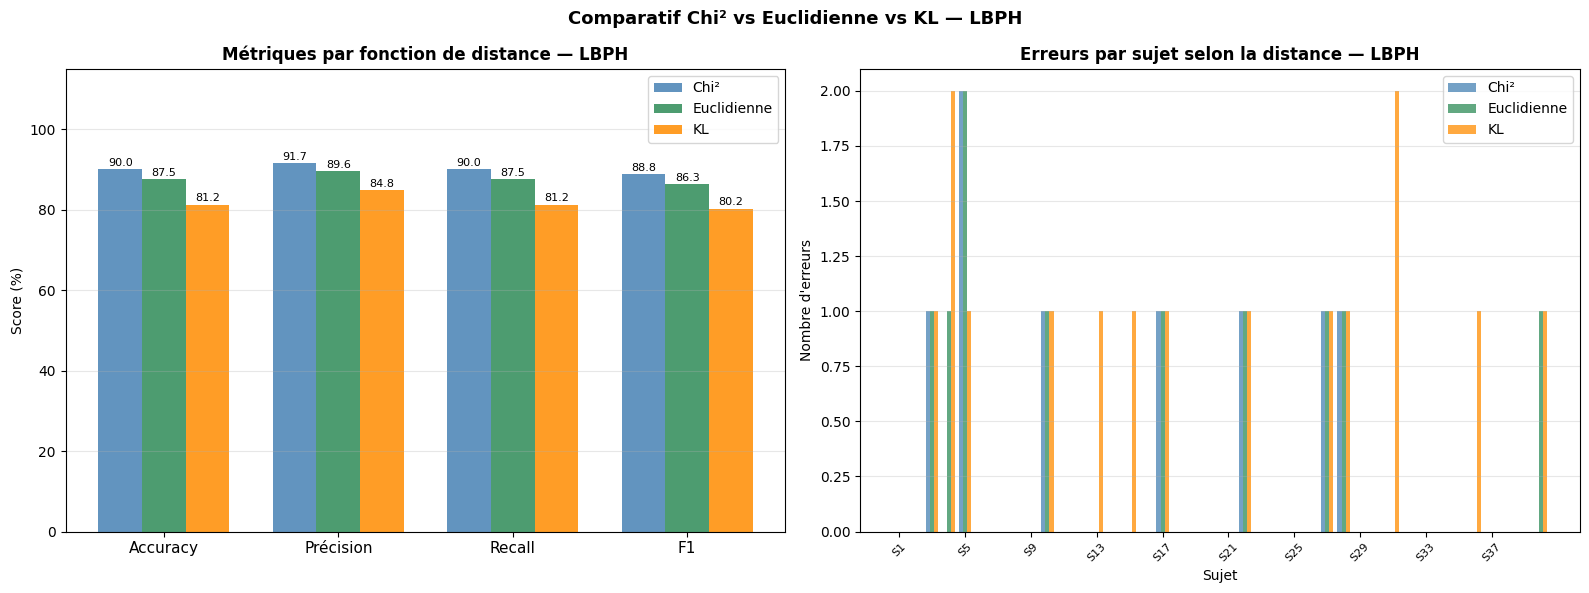

In [11]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compare_distances_lbph(X_test, y_test, subject_models, n_points, radius, method, block_size):
    """Évalue LBPH avec les 3 fonctions de distance et trace un comparatif."""
    results = {}

    for dist_name, dist_fn in DISTANCE_FUNCTIONS.items():
        print(f"Evaluation LBPH + {dist_name}...", end=" ", flush=True)
        t_start = time.time()
        y_pred_d, _, _ = predict_lbph(
            X_test, subject_models, n_points, radius, method, block_size,
            distance_fn=dist_fn
        )
        t_end = time.time()
        acc  = accuracy_score(y_test, y_pred_d)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_test, y_pred_d, average='macro', zero_division=0
        )
        results[dist_name] = {
            'y_pred': y_pred_d,
            'accuracy':   acc,
            'precision':  prec,
            'recall':     rec,
            'f1':         f1,
            'time_pred':  t_end - t_start,
        }
        print(f"Accuracy = {acc*100:.2f}%  |  F1 = {f1*100:.2f}%  |  t = {t_end-t_start:.4f}s")

    # ── Tableau récapitulatif ─────────────────────────────────────────────────
    print("\n" + "="*70)
    print("  COMPARATIF DES DISTANCES — LBPH")
    print("="*70)
    print(f"{'Distance':<15} {'Accuracy':>10} {'Précision':>10} {'Recall':>10} {'F1':>10} {'Temps (s)':>10}")
    print("-"*70)
    for name, r in results.items():
        print(f"{name:<15} {r['accuracy']*100:>9.2f}%  {r['precision']*100:>9.2f}%  "
              f"{r['recall']*100:>9.2f}%  {r['f1']*100:>9.2f}%  {r['time_pred']:>10.4f}")
    print("="*70)

    # ── Graphique 1 : Barres de métriques ─────────────────────────────────────
    metrics_keys = ['accuracy', 'precision', 'recall', 'f1']
    metrics_labels = ['Accuracy', 'Précision', 'Recall', 'F1']
    dist_names = list(results.keys())
    colors = ['steelblue', 'seagreen', 'darkorange']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    x = np.arange(len(metrics_keys))
    width = 0.25
    for i, (dist_name, color) in enumerate(zip(dist_names, colors)):
        vals = [results[dist_name][m] * 100 for m in metrics_keys]
        bars = ax.bar(x + i*width - width, vals, width,
                      label=dist_name, color=color, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_labels, fontsize=11)
    ax.set_ylabel("Score (%)")
    ax.set_ylim(0, 115)
    ax.set_title("Métriques par fonction de distance — LBPH", fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    # ── Graphique 2 : Erreurs par sujet ───────────────────────────────────────
    ax2 = axes[1]
    n_subjects = len(np.unique(y_test))
    errors_per_subject = {}
    for dist_name in dist_names:
        errs = []
        for sid in range(n_subjects):
            idx = np.where(y_test == sid)[0]
            errs.append(np.sum(results[dist_name]['y_pred'][idx] != sid))
        errors_per_subject[dist_name] = errs

    x2 = np.arange(n_subjects)
    w2 = 0.25
    for i, (dist_name, color) in enumerate(zip(dist_names, colors)):
        ax2.bar(x2 + i*w2 - w2, errors_per_subject[dist_name], w2,
                label=dist_name, color=color, alpha=0.75)
    ax2.set_xlabel("Sujet")
    ax2.set_ylabel("Nombre d'erreurs")
    ax2.set_title("Erreurs par sujet selon la distance — LBPH", fontweight='bold')
    ax2.set_xticks(x2[::4])
    ax2.set_xticklabels([f"S{i+1}" for i in range(0, n_subjects, 4)], rotation=45, fontsize=8)
    ax2.legend(fontsize=10)
    ax2.grid(axis='y', alpha=0.3)

    plt.suptitle("Comparatif Chi² vs Euclidienne vs KL — LBPH", fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    return results

dist_comparison_results = compare_distances_lbph(
    X_test, y_test, subject_models, N_POINTS, RADIUS, METHOD, BLOCK_SIZE
)

---
##  Méthode 2 — Eigenfaces 

### Principe

Pipeline :
1. Aplatir chaque image (112×92) en un vecteur de 10 304 dimensions
2. Appliquer une PCA : trouver les directions de variance maximale dans l'espace pixel  
   → les vecteurs propres sont les « eigenfaces » (visages fantômes)
3. Projeter chaque image dans l'espace PCA réduit (`N_COMPONENTS = 100`)
4. Classifier avec un SVM RBF dans cet espace compressé

Avantages :  
- Réduction de bruit (on ignore les composantes de faible variance)  
- Compression dimensionnelle : 10 304 → 100 dimensions  

Limites :
- Sensible aux variations d'éclairage et de pose (capture la variance globale)


Vecteurs aplatis — train : (320, 10304) | test : (80, 10304)

Variation du nombre de composantes PCA :
  n_components=  20 → variance expliquée:  70.5% | Accuracy: 96.25%
  n_components=  60 → variance expliquée:  84.6% | Accuracy: 95.00%
  n_components=  80 → variance expliquée:  87.8% | Accuracy: 95.00%
  n_components= 100 → variance expliquée:  90.2% | Accuracy: 96.25%
  n_components= 150 → variance expliquée:  94.2% | Accuracy: 91.25%


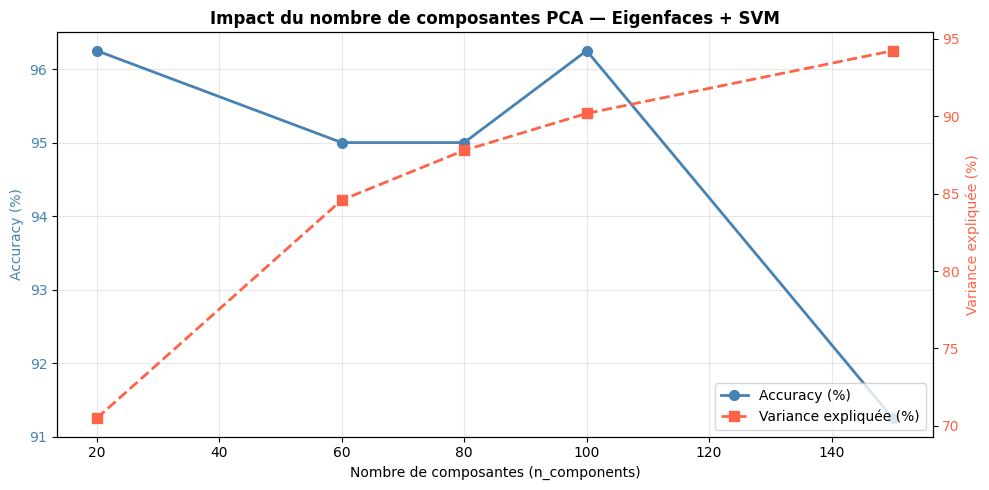


Meilleur n_components : 20 (Accuracy = 96.25%)

Application PCA avec 20 composantes...
Variance expliquée par 20 composantes : 70.5%
Shape après PCA — train : (320, 20) | test : (80, 20)
Temps PCA : 0.766s


In [20]:
from sklearn.decomposition import PCA

# ── 1. Aplatir les images ─────────────────────────────────────────────────────
X_train_flat = X_train.reshape(X_train.shape[0], -1).astype(np.float64)
X_test_flat  = X_test.reshape(X_test.shape[0],  -1).astype(np.float64)

print(f"Vecteurs aplatis — train : {X_train_flat.shape} | test : {X_test_flat.shape}")

# ── 2. Étude de l'impact du nombre de composantes PCA ────────────────────────
N_COMPONENTS_LIST = [20, 60, 80, 100, 150]
acc_by_ncomp = {}

print("\nVariation du nombre de composantes PCA :")
for n in N_COMPONENTS_LIST:
    pca_tmp = PCA(n_components=n, whiten=True)
    Xtr_tmp = pca_tmp.fit_transform(X_train_flat)
    Xte_tmp = pca_tmp.transform(X_test_flat)
    var_exp  = np.sum(pca_tmp.explained_variance_ratio_) * 100
    svm_tmp  = Pipeline([("sc", StandardScaler()), ("svm", SVC(kernel="rbf", C=10, gamma="scale"))])
    svm_tmp.fit(Xtr_tmp, y_train)
    acc_tmp  = accuracy_score(y_test, svm_tmp.predict(Xte_tmp)) * 100
    acc_by_ncomp[n] = (acc_tmp, var_exp)
    print(f"  n_components={n:4d} → variance expliquée: {var_exp:5.1f}% | Accuracy: {acc_tmp:.2f}%")

# ── Graphique variance & accuracy vs n_components ────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ns   = list(acc_by_ncomp.keys())
accs = [acc_by_ncomp[n][0] for n in ns]
vars_= [acc_by_ncomp[n][1] for n in ns]

ax1.plot(ns, accs,  "o-", color="steelblue", linewidth=2, markersize=7, label="Accuracy (%)")
ax2.plot(ns, vars_, "s--", color="tomato",   linewidth=2, markersize=7, label="Variance expliquée (%)")

ax1.set_xlabel("Nombre de composantes (n_components)")
ax1.set_ylabel("Accuracy (%)", color="steelblue")
ax2.set_ylabel("Variance expliquée (%)", color="tomato")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="tomato")
ax1.set_title("Impact du nombre de composantes PCA — Eigenfaces + SVM", fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Choisir le meilleur n_components ─────────────────────────────────────────
best_n = max(acc_by_ncomp, key=lambda n: acc_by_ncomp[n][0])
print(f"\nMeilleur n_components : {best_n} (Accuracy = {acc_by_ncomp[best_n][0]:.2f}%)")

# ── 2. PCA finale avec le meilleur n ─────────────────────────────────────────
N_COMPONENTS = best_n
print(f"\nApplication PCA avec {N_COMPONENTS} composantes...")
t7 = time.time()
pca = PCA(n_components=N_COMPONENTS, whiten=True)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca  = pca.transform(X_test_flat)
t8 = time.time()

variance_cumulee = np.sum(pca.explained_variance_ratio_) * 100
print(f"Variance expliquée par {N_COMPONENTS} composantes : {variance_cumulee:.1f}%")
print(f"Shape après PCA — train : {X_train_pca.shape} | test : {X_test_pca.shape}")
print(f"Temps PCA : {t8-t7:.3f}s")


### 2.1 Visualisation des Eigenfaces

Les premières composantes capturent les variations globales (éclairage, pose) ;  
les composantes suivantes encodent des détails de plus en plus fins.


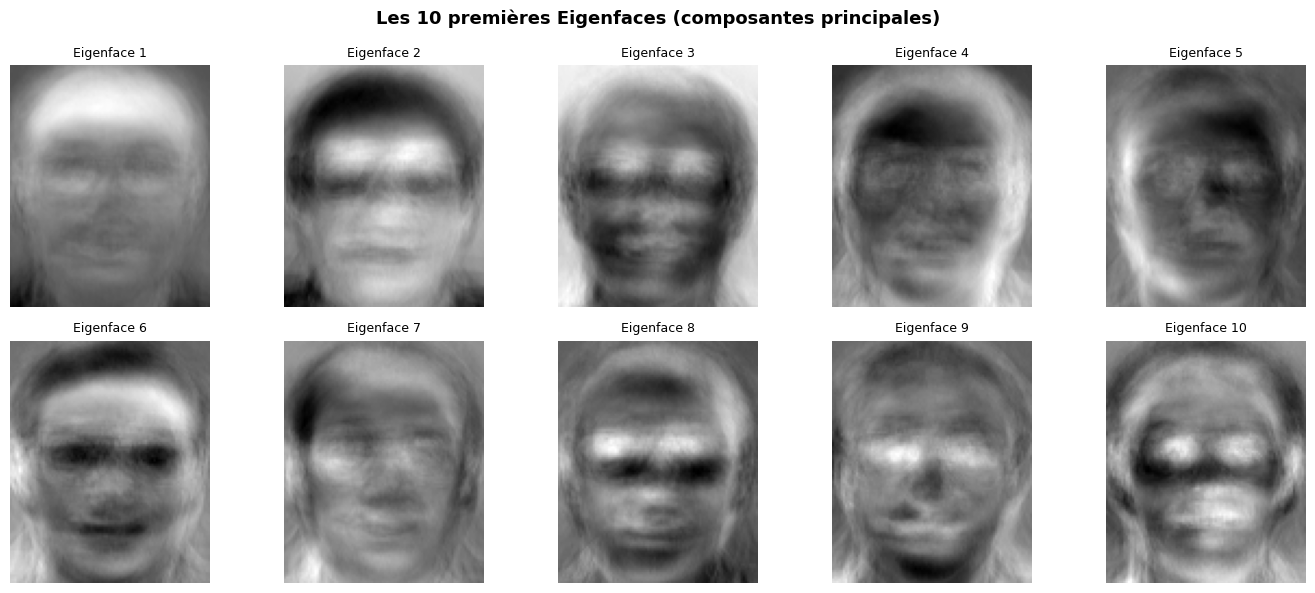

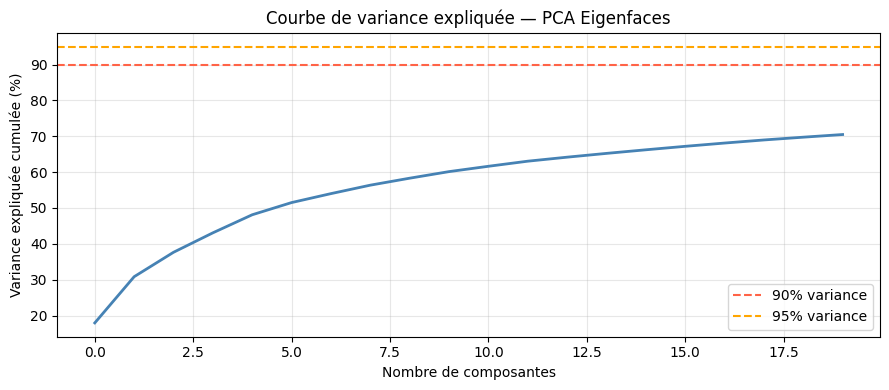

In [21]:
# ── Visualisation des Eigenfaces ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    eigenface = pca.components_[i].reshape(112, 92)
    ax.imshow(eigenface, cmap="gray")
    ax.set_title(f"Eigenface {i+1}", fontsize=9)
    ax.axis("off")
plt.suptitle("Les 10 premières Eigenfaces (composantes principales)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Courbe de variance expliquée cumulée ──────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100,
         color="steelblue", linewidth=2)
plt.axhline(y=90, color="tomato",  linestyle="--", label="90% variance")
plt.axhline(y=95, color="orange",  linestyle="--", label="95% variance")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée (%)")
plt.title("Courbe de variance expliquée — PCA Eigenfaces")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 🧍 Visage moyen (Mean Face)

Avant de visualiser les eigenfaces, on calcule le **visage moyen** :
- Le **visage moyen global** est la moyenne de toutes les 320 images d'entraînement : il représente un visage "neutre" du dataset.
- Les **visages moyens par sujet** montrent la texture et la structure faciale caractéristique de chaque personne.

La PCA est appliquée **sur les écarts** par rapport à ce visage moyen — les eigenfaces captent donc les directions de variation les plus importantes autour de cette référence.


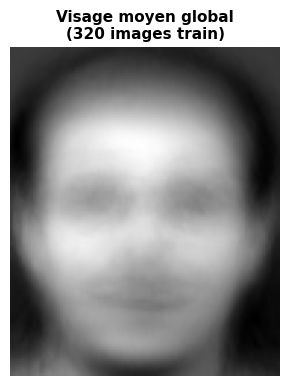

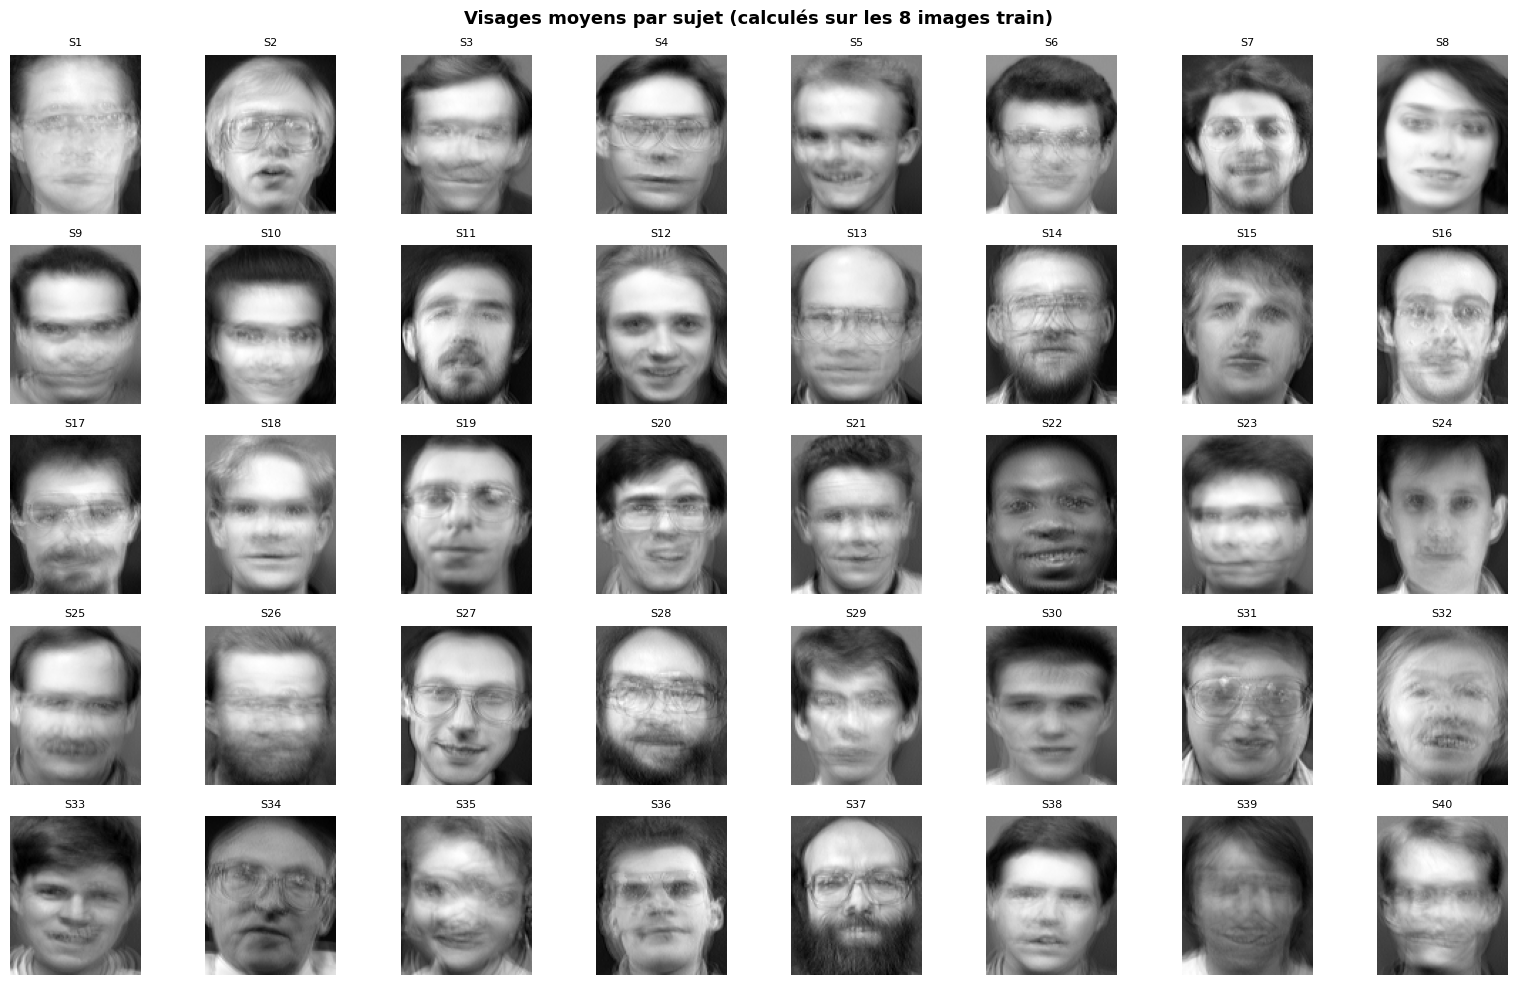

In [14]:
# ── Visage moyen global et par sujet ─────────────────────────────────────────

# Visage moyen global (sur tout le train)
mean_face_global = X_train_flat.mean(axis=0).reshape(112, 92)

# Visage moyen par sujet
mean_faces = []
for subject_id in range(40):
    idx = np.where(y_train == subject_id)[0]
    mean_face = X_train_flat[idx].mean(axis=0).reshape(112, 92)
    mean_faces.append(mean_face)

# ── Affichage du visage moyen global ─────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(3, 4))
ax.imshow(mean_face_global, cmap="gray")
ax.set_title("Visage moyen global\n(320 images train)", fontsize=11, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

# ── Affichage des visages moyens par sujet ────────────────────────────────────
fig, axes = plt.subplots(5, 8, figsize=(16, 10))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(mean_faces[i], cmap="gray")
    ax.set_title(f"S{i+1}", fontsize=8)
    ax.axis("off")
plt.suptitle("Visages moyens par sujet (calculés sur les 8 images train)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 2.2 Entraînement du SVM dans l'espace PCA

In [25]:
# ── 3. SVM sur espace PCA ────────────────────────────────────────────────────
eigenface_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=10, gamma="scale", decision_function_shape="ovr"))
])

print("Entraînement SVM sur features Eigenfaces...")
t9  = time.time()
eigenface_svm.fit(X_train_pca, y_train)
t10 = time.time()
TIME_EIG_TRAIN = t10 - t9

t11 = time.time()
y_pred_eig = eigenface_svm.predict(X_test_pca)
t12 = time.time()
TIME_EIG_PRED = t12 - t11

print(f"Entraînement terminé en {TIME_EIG_TRAIN:.3f}s")
print(f"Accuracy Eigenfaces : {accuracy_score(y_test, y_pred_eig)*100:.2f}%")


Entraînement SVM sur features Eigenfaces...
Entraînement terminé en 0.023s
Accuracy Eigenfaces : 96.25%


---
## Évaluation comparative — LBPH vs Eigenfaces

Nous comparons les deux méthodes sur les **mêmes données de test** (80 images, seed=42).  
Les métriques rapportées sont calculées en **moyenne macro** sur les 40 classes.



  LBPH + Chi² (block=8)
  Accuracy  :  90.00%
  Précision :  91.67%  (macro)
  Recall    :  90.00%  (macro)
  F1-score  :  88.83%  (macro)
  Train     : 7.759s
  Prédiction: 1.9340s


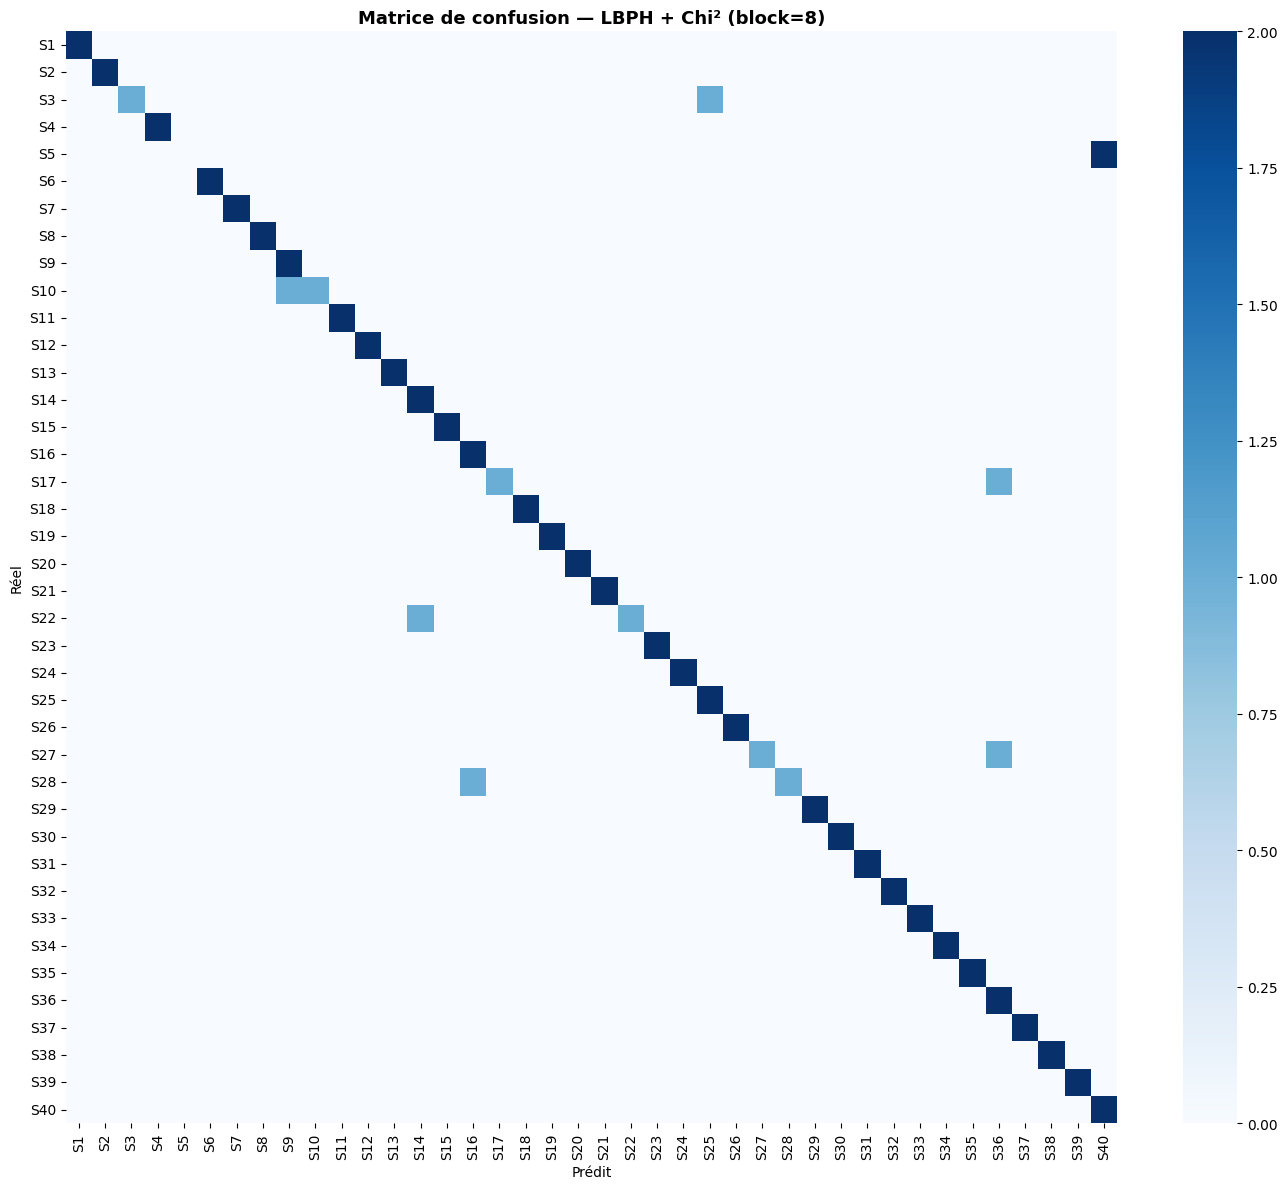

In [16]:
def full_evaluate(y_test, y_pred, method_name, time_train=None, time_pred=None):
    """Évalue une méthode et retourne un dict résumé."""
    acc  = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    print(f"\n{'='*55}")
    print(f"  {method_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc*100:6.2f}%")
    print(f"  Précision : {prec*100:6.2f}%  (macro)")
    print(f"  Recall    : {rec*100:6.2f}%  (macro)")
    print(f"  F1-score  : {f1*100:6.2f}%  (macro)")
    if time_train: print(f"  Train     : {time_train:.3f}s")
    if time_pred:  print(f"  Prédiction: {time_pred:.4f}s")
    print(f"{'='*55}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=False, cmap="Blues",
                xticklabels=[f"S{i+1}" for i in range(40)],
                yticklabels=[f"S{i+1}" for i in range(40)])
    plt.title(f"Matrice de confusion — {method_name}", fontsize=13, fontweight="bold")
    plt.xlabel("Prédit"); plt.ylabel("Réel")
    plt.tight_layout(); plt.show()

    return {"Méthode": method_name, "Accuracy": acc,
            "Précision": prec, "Recall": rec, "F1": f1,
            "Train (s)": round(time_train, 3) if time_train else "—",
            "Pred (s)":  round(time_pred,  4) if time_pred  else "—"}

# ── Évaluation LBPH ───────────────────────────────────────────────────────────
results_lbph = full_evaluate(
    y_test, y_pred_lbph,
    method_name=f"LBPH + Chi² (block={BLOCK_SIZE})",
    time_train=TIME_LBPH_TRAIN, time_pred=TIME_LBPH_PRED
)



  Eigenfaces PCA(20) + SVM
  Accuracy  :  96.25%
  Précision :  97.92%  (macro)
  Recall    :  96.25%  (macro)
  F1-score  :  96.17%  (macro)
  Train     : 0.023s
  Prédiction: 0.0036s


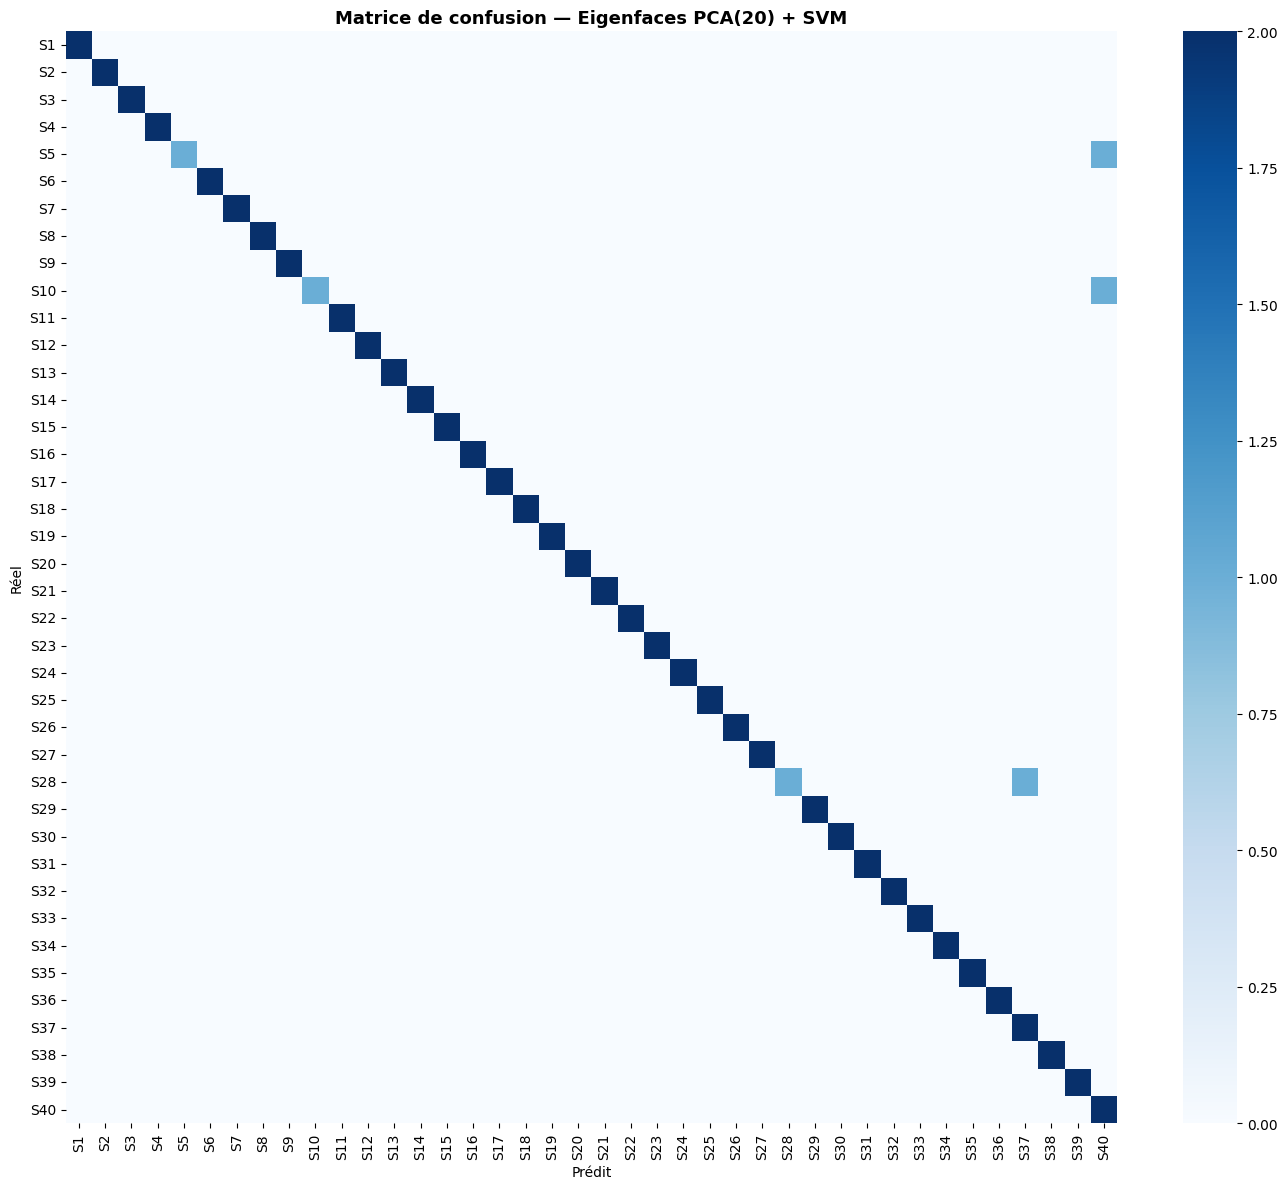

In [26]:
# ── Évaluation Eigenfaces ─────────────────────────────────────────────────────
results_eig = full_evaluate(
    y_test, y_pred_eig,
    method_name=f"Eigenfaces PCA({N_COMPONENTS}) + SVM",
    time_train=TIME_EIG_TRAIN, time_pred=TIME_EIG_PRED
)


### Tableau récapitulatif et graphique comparatif


  TABLEAU RÉCAPITULATIF — LBPH vs Eigenfaces
                 Méthode Accuracy Précision Recall     F1  Train (s)  Pred (s)
   LBPH + Chi² (block=8)    90.0%    91.67%  90.0% 88.83%      7.759    1.9340
Eigenfaces PCA(20) + SVM   96.25%    97.92% 96.25% 96.17%      0.023    0.0036


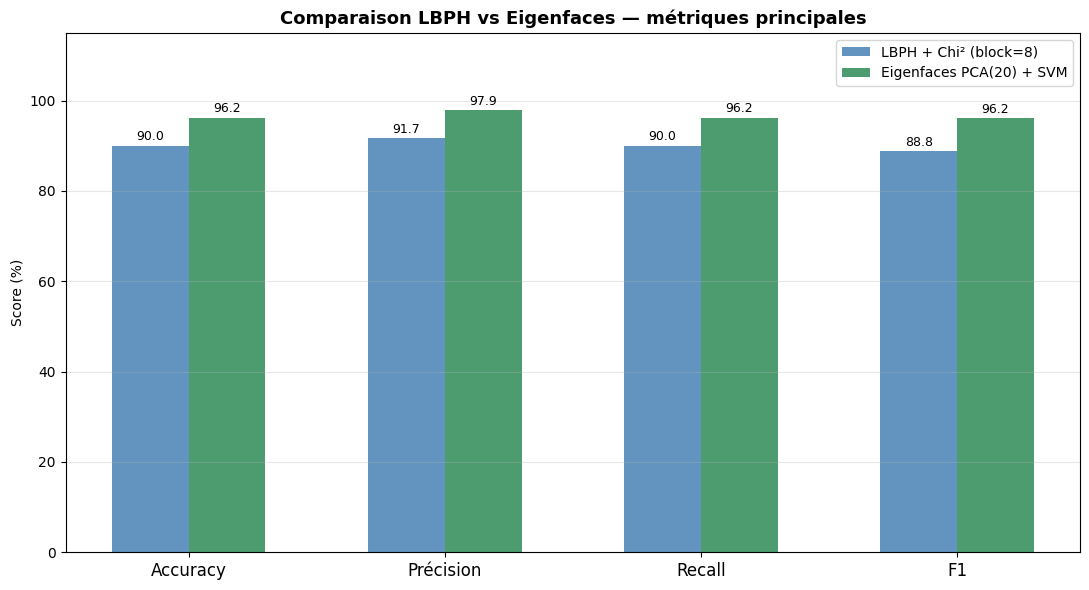

In [27]:
# ── Tableau ───────────────────────────────────────────────────────────────────
results_all = [results_lbph, results_eig]
df = pd.DataFrame(results_all)

df_display = df.copy()
for col in ["Accuracy", "Précision", "Recall", "F1"]:
    df_display[col] = (df_display[col] * 100).round(2).astype(str) + "%"

print("\n" + "="*70)
print("  TABLEAU RÉCAPITULATIF — LBPH vs Eigenfaces")
print("="*70)
print(df_display.to_string(index=False))
print("="*70)

# ── Graphique comparatif ──────────────────────────────────────────────────────
metrics = ["Accuracy", "Précision", "Recall", "F1"]
fig, ax = plt.subplots(figsize=(11, 6))
x, width = np.arange(len(metrics)), 0.30
colors   = ["steelblue", "seagreen"]

for i, (row, color) in enumerate(zip(results_all, colors)):
    vals = [row["Accuracy"]*100, row["Précision"]*100,
            row["Recall"]*100,   row["F1"]*100]
    bars = ax.bar(x + i*width - width/2, vals, width,
                  label=row["Méthode"], color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{v:.1f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 115)
ax.set_title("Comparaison LBPH vs Eigenfaces — métriques principales",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Analyse des erreurs — images mal classées

Visualiser les images mal classifiées aide à comprendre les cas limites :  
expressions inhabituelles, éclairage atypique, ressemblance inter-sujets.


=== LBPH — erreurs avec comparaison réel / prédit ===

LBPH + Chi² (block=8) : 8 erreur(s) sur 80 images


/tmp/ipykernel_55/4009254100.py:64: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_55/4009254100.py:64: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


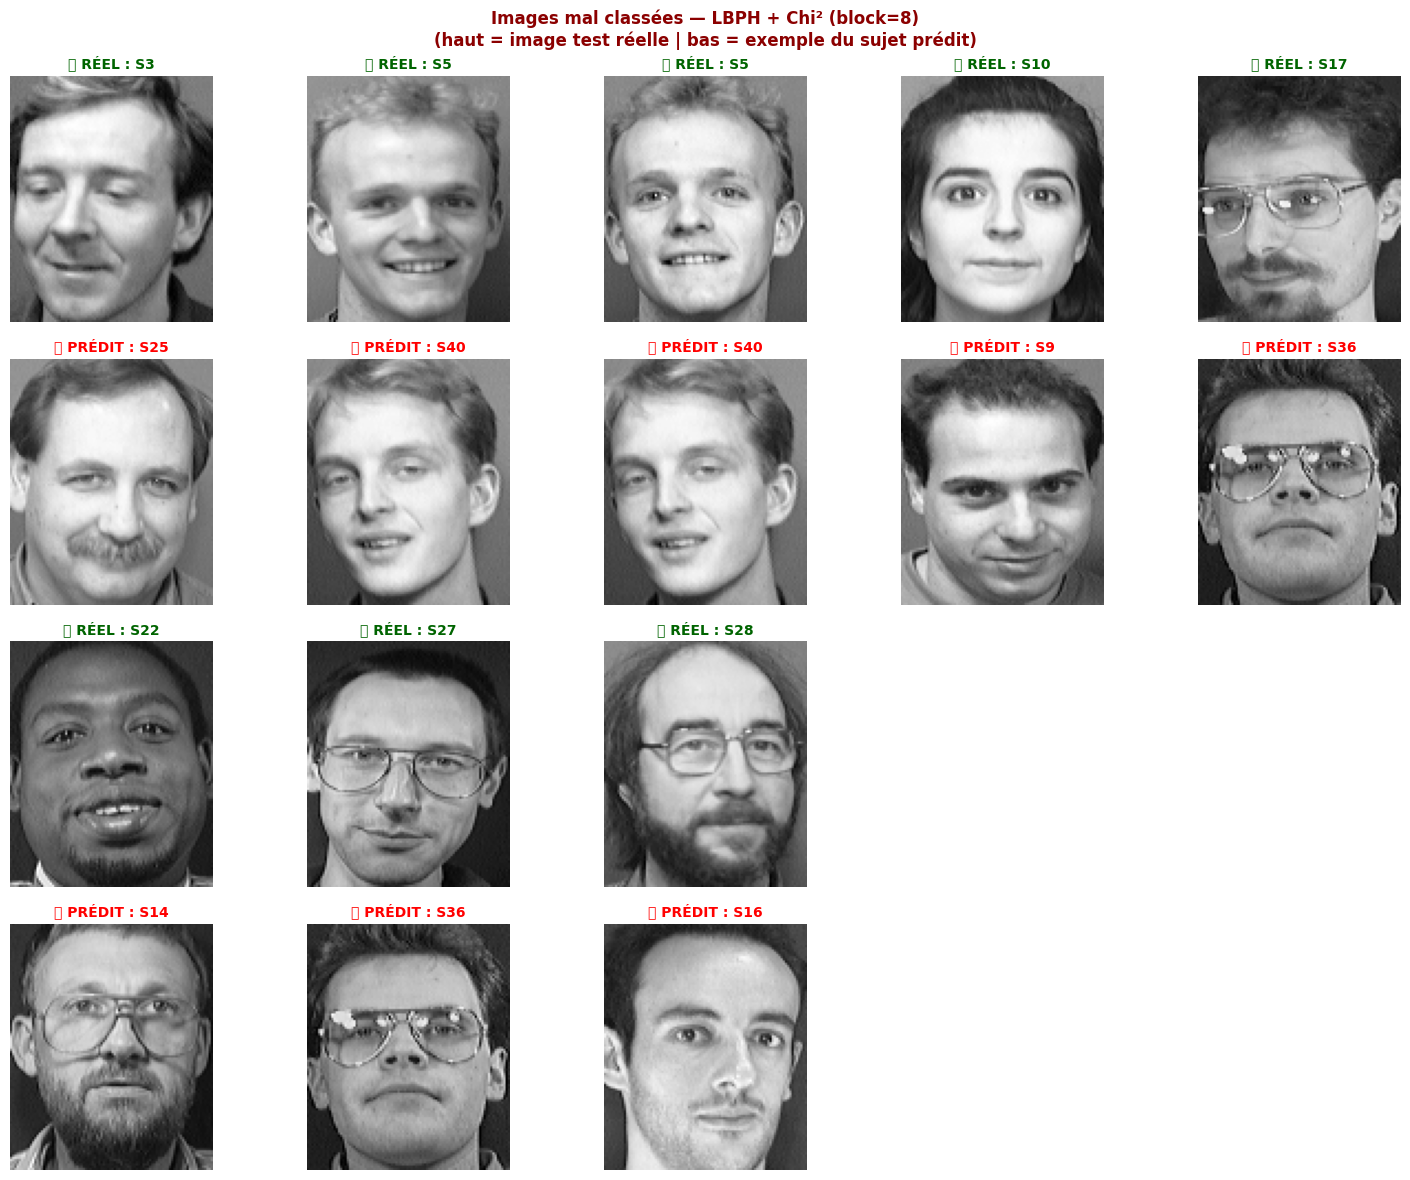


=== Eigenfaces — images mal classées ===

Eigenfaces PCA(20) + SVM : 3 erreur(s) sur 80 images


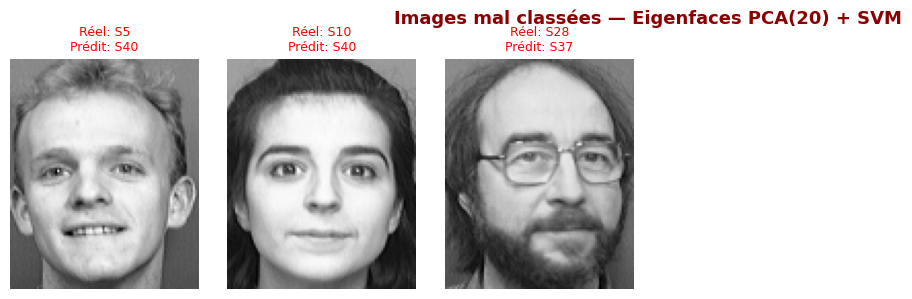

In [28]:
def plot_misclassified(X_test, y_test, y_pred, method_name, max_show=10,
                       X_train=None, y_train=None, show_predicted_face=False):
    """
    Affiche les images mal classées.
    Si show_predicted_face=True et X_train/y_train fournis :
      - Colonne gauche  : image test (sujet réel)
      - Colonne droite  : image train du sujet prédit (pour comparaison)
    """
    errors = np.where(y_test != y_pred)[0]
    print(f"\n{method_name} : {len(errors)} erreur(s) sur {len(y_test)} images")
    if len(errors) == 0:
        print("✅ Classification parfaite !"); return

    n_show = min(len(errors), max_show)

    if show_predicted_face and X_train is not None and y_train is not None:
        # ── Mode côte à côte : (réel | prédit) ────────────────────────────────
        n_cols = min(n_show, 5)
        n_rows = int(np.ceil(n_show / n_cols))
        fig, axes = plt.subplots(n_rows * 2, n_cols,
                                 figsize=(n_cols * 3, n_rows * 6))
        if n_rows * 2 == 2 and n_cols == 1:
            axes = axes.reshape(2, 1)
        elif n_rows * 2 == 2:
            axes = axes.reshape(2, n_cols)
        # axes shape : (2*n_rows, n_cols)

        for k, idx in enumerate(errors[:n_show]):
            row_top = (k // n_cols) * 2
            row_bot = row_top + 1
            col     = k % n_cols

            real_sid = y_test[idx]
            pred_sid = y_pred[idx]

            # Image test (sujet réel)
            ax_real = axes[row_top, col]
            ax_real.imshow(X_test[idx], cmap='gray')
            ax_real.set_title(f"✅ RÉEL : S{real_sid+1}", fontsize=10,
                              color='darkgreen', fontweight='bold')
            ax_real.axis('off')

            # Une image du sujet prédit (prise dans le train)
            pred_train_idx = np.where(y_train == pred_sid)[0][0]
            ax_pred = axes[row_bot, col]
            ax_pred.imshow(X_train[pred_train_idx], cmap='gray')
            ax_pred.set_title(f"❌ PRÉDIT : S{pred_sid+1}", fontsize=10,
                              color='red', fontweight='bold')
            ax_pred.axis('off')

        # Cacher les axes inutilisés
        for k in range(n_show, n_rows * n_cols):
            row_top = (k // n_cols) * 2
            row_bot = row_top + 1
            col     = k % n_cols
            if row_top < axes.shape[0]:
                axes[row_top, col].set_visible(False)
            if row_bot < axes.shape[0]:
                axes[row_bot, col].set_visible(False)

        plt.suptitle(f"Images mal classées — {method_name}\n"
                     f"(haut = image test réelle | bas = exemple du sujet prédit)",
                     fontsize=12, fontweight='bold', color='darkred')
        plt.tight_layout(); plt.show()

    else:
        # ── Mode classique : image seule ──────────────────────────────────────
        n_cols = 6
        n_rows = int(np.ceil(n_show / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2.2, n_rows*3))
        axes = np.array(axes).ravel()
        for i, idx in enumerate(errors[:n_show]):
            axes[i].imshow(X_test[idx], cmap='gray')
            axes[i].set_title(f"Réel: S{y_test[idx]+1}\nPrédit: S{y_pred[idx]+1}",
                              fontsize=9, color='red')
            axes[i].axis('off')
        for j in range(n_show, len(axes)):
            axes[j].set_visible(False)
        plt.suptitle(f"Images mal classées — {method_name}",
                     fontsize=13, fontweight='bold', color='darkred')
        plt.tight_layout(); plt.show()

# ── Affichage LBPH : côte à côte (réel | prédit) ─────────────────────────────
print("=== LBPH — erreurs avec comparaison réel / prédit ===")
plot_misclassified(
    X_test, y_test, y_pred_lbph,
    method_name=f"LBPH + Chi² (block={BLOCK_SIZE})",
    max_show=10,
    X_train=X_train, y_train=y_train,
    show_predicted_face=True
)

# ── Affichage Eigenfaces : mode classique ──────────────────────────────────────
print("\n=== Eigenfaces — images mal classées ===")
plot_misclassified(
    X_test, y_test, y_pred_eig,
    method_name=f"Eigenfaces PCA({N_COMPONENTS}) + SVM",
    max_show=12
)

---
##  Conclusion

### Synthèse des méthodes

| Méthode | Type | Descripteur | Classifieur |
|---|---|---|---|
| **LBPH + Chi²** | Sans apprentissage | Textures locales (LBP par blocs) | Distance Chi² |
| **Eigenfaces** | Apprentissage ML | Structure globale (PCA) | SVM RBF |

### Enseignements clés

- **LBPH** : rapide, sans phase d'entraînement explicite, robuste aux variations d'éclairage  
  car il travaille sur les **gradients locaux**. Limite : la comparaison Chi² est moins  
  flexible qu'un classifieur appris.

- **Eigenfaces** : méthode de référence historique, efficace grâce à la compression PCA  
  et la puissance du SVM. Plus sensible à l'éclairage et à la pose  
  car la PCA capture la **variance globale** des pixels.

- Avec seulement **2 images de test par sujet**, les métriques sont sensibles au split  
  aléatoire. Une validation croisée (k-fold) donnerait des résultats plus stables.

### Pistes d'amélioration

- **Validation croisée** pour des résultats plus robustes  
- **Combinaison LBPH + Eigenfaces** (fusion de features) pour un descripteur plus riche  
- **Augmentation de données** (flip, bruit gaussien) pour améliorer la généralisation  
- **Deep Learning** (FaceNet, ArcFace) pour des benchmarks sur datasets plus difficiles (LFW, etc.)
